# IWSLT14 German → English Transformer (Phase 2)

Phase 2: rebuilding the phase 1 (IWSLT17) pipeline for the canonical IWSLT14 de-en benchmark, so results are directly comparable to published work. Planned additions on top of the phase 1 base: relative positional encoding, a short-to-long sequence-length training curriculum, and AdamW from the start. Phase 1's finished result is preserved at git tag `v1-iwslt17` and in `phase1_iwslt17.ipynb`.

In [1]:
import yaml
import torch

In [2]:
with open("config_iwslt14.yaml", "r") as f:
    config = yaml.safe_load(f)

device = torch.device(config['experiment']['device'] if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
if torch.cuda.is_available():
    # Disable Flash Attention lookup (suppresses Windows build warning)
    torch.backends.cuda.enable_flash_sdp(False)
    
    # Enable Memory-Efficient Attention & cuDNN Attention
    torch.backends.cuda.enable_mem_efficient_sdp(True)
    torch.backends.cuda.enable_math_sdp(True)

## Data Preparation

In [4]:
RESET_DATASET = False  # set True to wipe cached data/tokenizers and force a rebuild

if RESET_DATASET:
    from data_management import reset_dataset_cache
    reset_dataset_cache(folders=('./data_iwslt14', './cache_iwslt14', './models_iwslt14'))

In [5]:
from data_preparation import prepare_data_iwslt14
from dataset import create_single_dataloader, create_token_budget_dataloader

USE_BPE_DROPOUT = True  # set False to train on fixed pre-tokenized ids like before
MAX_TOKENS = 2048  # token-budget batching target -- see the Training section for how this was picked

# 1. Download (canonical IWSLT14 de-en split, see data_preparation.py), tokenize,
# and load splits from cache
train_de, train_en, val_de, val_en, test_de, test_en, de_tok, en_tok, train_src_raw, train_tgt_raw = prepare_data_iwslt14(
    config=config,
    force_rebuild=False
)

# Reference lengths for token-budget batching (and, later, curriculum
# staging) -- computed once from the deterministic tokenization, stable
# regardless of BPE dropout resampling a sentence's actual split each epoch.
pair_lengths = [max(len(s), len(t)) for s, t in zip(train_de, train_en)]

# 2. Build Train and Val loaders. Batched by token budget instead of a fixed
# sentence count -- short sentences pack many-per-batch, long ones few-per-
# batch, instead of every batch being padded to whatever the longest sentence
# in it happens to be regardless of how short the rest are.
if USE_BPE_DROPOUT:
    # On-the-fly sampled tokenization — same sentence segments differently each
    # epoch, unlike the fixed pre-tokenized ids used everywhere else.
    train_loader = create_token_budget_dataloader(
        lengths=pair_lengths, max_tokens=MAX_TOKENS,
        src_texts=train_src_raw, tgt_texts=train_tgt_raw,
        src_tokenizer=de_tok, tgt_tokenizer=en_tok,
        alpha=config['training'].get('bpe_dropout_alpha', 0.1),
        shuffle=True
    )
else:
    train_loader = create_token_budget_dataloader(
        lengths=pair_lengths, max_tokens=MAX_TOKENS,
        src_encoded=train_de, tgt_encoded=train_en,
        shuffle=True
    )

val_loader = create_single_dataloader(
    src_encoded=val_de,
    tgt_encoded=val_en,
    batch_size=config['training']['batch_size'],
    shuffle=False,
    num_workers=config['training'].get('num_workers', 0)
)

# 3. Build Test loader independently
test_loader = create_single_dataloader(
    src_encoded=test_de,
    tgt_encoded=test_en,
    batch_size=config['training']['batch_size'],
    shuffle=False,
    num_workers=config['training'].get('num_workers', 0)
)

print(f"DataLoaders ready! Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

C:\Users\Tommi\Desktop\Transformer\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[data_prep] Loading pre-tokenized IWSLT14 dataset from cache './cache_iwslt14\processed_token_data.pkl'...
DataLoaders ready! Train: 2138 | Val: 114 | Test: 106


In [6]:
RUN_BENCHMARKS = True  # set True to time the dataloader in isolation from GPU compute

if RUN_BENCHMARKS:
    from benchmarking import benchmark_dataloader
    benchmark_dataloader(train_loader, num_batches=100)
else:
    print("RUN_BENCHMARKS is False — skipping dataloader speed test.")

Time taken for 100 DataLoader batches: 0.99 seconds


In [7]:
from inspection import inspect_dataset_samples
# Inspect 3 samples from the training set
inspect_dataset_samples(
    src_encoded=train_de,
    tgt_encoded=train_en,
    src_tokenizer=de_tok,
    tgt_tokenizer=en_tok,
    num_samples=3,
    start_idx=0
)

 DATASET INSPECTION (3 samples starting from index 0)

--- [ Sample #1 ] ---

🇩🇪 SOURCE (German):
  • Plain Text: Das Meer kann ziemlich kompliziert sein.
  • Token IDs (9): [1, 182, 1898, 247, 976, 6062, 232, 9944, 2]
  • Subword Pieces: ['<s>', '▁Das', '▁Meer', '▁kann', '▁ziemlich', '▁kompliziert', '▁sein', '.', '</s>']

🇬🇧 TARGET (English):
  • Plain Text: It can be a very complicated thing, the ocean.
  • Token IDs (13): [1, 177, 116, 61, 6, 228, 2724, 212, 9953, 8, 1687, 9955, 2]
  • Subword Pieces: ['<s>', '▁It', '▁can', '▁be', '▁a', '▁very', '▁complicated', '▁thing', ',', '▁the', '▁ocean', '.', '</s>']

--- [ Sample #2 ] ---

🇩🇪 SOURCE (German):
  • Plain Text: Und was menschliche Gesundheit ist, kann auch ziemlich kompliziert sein.
  • Token IDs (14): [1, 111, 192, 2034, 1370, 58, 9941, 247, 258, 976, 6062, 232, 9944, 2]
  • Subword Pieces: ['<s>', '▁Und', '▁was', '▁menschliche', '▁Gesundheit', '▁ist', ',', '▁kann', '▁auch', '▁ziemlich', '▁kompliziert', '▁sein', '.', '</s>']

🇬

## Hyperparameter Tuning (Optuna)

In [8]:
RUN_TUNING = False  # set True to run the Optuna hyperparameter search (slow)

if RUN_TUNING:
    from tuning import run_hyperparameter_search
    study = run_hyperparameter_search(
        train_loader, val_loader, config, device,
        n_trials=38,
        study_name="transformer_tuning_iwslt14",
        best_params_path="best_params_iwslt14.json",
        storage="sqlite:///optuna_study_iwslt14.db",
    )
else:
    print("RUN_TUNING is False — skipping hyperparameter search.")

RUN_TUNING is False — skipping hyperparameter search.


In [9]:
# Manual recovery: use this if RUN_TUNING above got interrupted (kernel restart,
# stalled/swapped to RAM, KeyboardInterrupt, etc.) before it could save best_params.json
# automatically. Completed trials persist in the storage DB regardless of how the
# process ended, so this just reloads the study and saves the best result found so far.
import optuna
from tuning import save_best_params

RUN_MANUAL_RECOVERY = False  # set True only if RUN_TUNING above got interrupted before saving results

if RUN_MANUAL_RECOVERY:
    study = optuna.load_study(study_name="transformer_tuning_iwslt14", storage="sqlite:///optuna_study_iwslt14.db")
    save_best_params(study, best_params_path="best_params_iwslt14.json")

In [10]:
import json

APPLY_BEST_PARAMS = True  # set False to train with the base config.yaml architecture instead

if APPLY_BEST_PARAMS:
    with open("best_params_iwslt14.json", "r") as f:
        best_params_record = json.load(f)

    best_params = best_params_record["best_params"]
    print(
        f"Applying best params from trial {best_params_record['best_trial_number']} "
        f"(val_loss={best_params_record['best_value']:.4f}):\n{json.dumps(best_params, indent=2)}"
    )

    config['model']['d_model'] = best_params['d_model']
    config['model']['num_heads'] = best_params['nhead']
    config['model']['num_enc_layers'] = best_params['num_encoder_layers']
    config['model']['num_dec_layers'] = best_params['num_decoder_layers']
    config['model']['dropout'] = best_params['dropout']

    # weight_decay wasn't tunable in older best_params.json files — fall back to the
    # existing config value if this one predates that change, rather than KeyError.
    config['training']['weight_decay'] = best_params.get(
        'weight_decay', config['training'].get('weight_decay', 0.01)
    )

    # NOTE: best_params['lr'] is intentionally NOT applied below. Tuning trials used a
    # flat Adam lr with no schedule (tuning.py), but the final run below uses
    # CustomWarmupSchedule (Noam-style), which computes its own peak LR from
    # d_model/warmup_steps and expects optimizer lr=1.0 as a multiplier. The tuned lr
    # value isn't directly comparable/transferable to that setup.
else:
    print("APPLY_BEST_PARAMS is False — training with the base config.yaml architecture.")

Applying best params from trial 32 (val_loss=3.3577):
{
  "d_model": 512,
  "nhead": 8,
  "num_encoder_layers": 5,
  "num_decoder_layers": 6,
  "dropout": 0.11630150706337157,
  "weight_decay": 0.0001720515681267549
}


## Model & Trainer Setup

In [11]:
from model import Transformer  # Ensure model.py defines your Transformer class


src_vocab_size = de_tok.vocab_size
tgt_vocab_size = en_tok.vocab_size

# dff computed from whichever d_model actually gets used (base config or a
# tuned trial), not read as a separate static config value — APPLY_BEST_PARAMS
# above only overrides d_model, so a static dff would silently drift from the
# intended 2x ratio whenever tuning picks a different d_model than the base
# config's. (This is exactly what happened in phase 1: its tuned checkpoint
# used d_model=256 but dff stayed at the base config's 2048 — an 8x ratio,
# not the intended 4x.)
dff = 2 * config['model']['d_model']

model = Transformer(
    num_enc_layers=config['model']['num_enc_layers'],
    num_dec_layers=config['model']['num_dec_layers'],
    d_model=config['model']['d_model'],
    num_heads=config['model']['num_heads'],
    dff=dff,
    src_vocab=src_vocab_size,
    tgt_vocab=tgt_vocab_size,
    rate=config['model']['dropout']
).to(device)

# 4. Count total trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Transformer instantiated successfully!")
print(f"  • Source Vocab Size: {src_vocab_size:,}")
print(f"  • Target Vocab Size: {tgt_vocab_size:,}")
print(f"  • Total Trainable Parameters: {trainable_params:,}")

Transformer instantiated successfully!
  • Source Vocab Size: 10,000
  • Target Vocab Size: 10,000
  • Total Trainable Parameters: 44,812,560


In [12]:
if RUN_BENCHMARKS:
    import torch.nn as nn
    from benchmarking import benchmark_step_time

    # benchmark_step_time deep-copies model internally and benchmarks that
    # disposable copy — the real model/its weights are never touched here.
    criterion = nn.CrossEntropyLoss(
        label_smoothing=config['training'].get('label_smoothing_eps', 0.1),
        ignore_index=config['data'].get('pad_id', 0)
    )
    benchmark_step_time(model, criterion, train_loader, device)
else:
    print("RUN_BENCHMARKS is False — skipping GPU step-time benchmark.")

Warming up GPU...


C:\Users\Tommi\Desktop\Transformer\model.py:96: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:455.)
  out = F.scaled_dot_product_attention(


Benchmarking 20 steps...

Pure GPU compute time per batch step: 81.66 ms


In [13]:
from tracker import ExperimentLogger
from trainer import Trainer
from scheduling import CustomWarmupSchedule


# Load best config from Optuna search
logger = ExperimentLogger(
    config=config,
    group="final_model",
    run_name="transformer_best_run"
)

# 1. AdamW with weight decay excluded from 1D params (biases, LayerNorm gains).
# Phase 1 found that applying weight decay uniformly via plain (non-decoupled)
# Adam silently collapsed the encoder's self-attention query/key weights to
# an exact-zero fixed point over the course of training — invisible in the
# loss curve, only obvious once attention was actually visualized. AdamW
# decouples decay from the gradient, and excluding 1D params from decay is
# standard transformer practice; applying both from the start here means this
# phase doesn't need a diagnose-and-fine-tune-afterward step like phase 1 did.
# (Set lr=1.0 because CustomWarmupSchedule scales base_lr directly.)
decay, no_decay = [], []
for p in model.parameters():
    (no_decay if p.dim() == 1 else decay).append(p)

optimizer = torch.optim.AdamW(
    [
        {"params": decay, "weight_decay": config['training'].get('weight_decay', 0.01)},
        {"params": no_decay, "weight_decay": 0.0},
    ],
    lr=1.0,
    betas=(0.9, 0.98),
    eps=1e-9
)

# 2. Instantiate CustomWarmupSchedule with your class name
scheduler = CustomWarmupSchedule(
    optimizer=optimizer,
    d_model=config['model']['d_model'],
    warmup_steps=config['training'].get('warmup_steps', 4000)
)

# 3. Mixed Precision Scaler
scaler = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda'))

# 4. Instantiate SingleGPUTrainer
trainer = Trainer(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    scaler=scaler,
    device=device,
    config=config,
    logger=logger
)

print("Optimizer, CustomWarmupSchedule, Scaler, and Trainer successfully initialized!")

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Tommi\.netrc.
wandb: Currently logged in as: purplewaterfall (rl_project1) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb: Detected [huggingface_hub.inference] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai


Optimizer, CustomWarmupSchedule, Scaler, and Trainer successfully initialized!


## Training

Sequence-length curriculum: trains on progressively longer sentences across 4 stages instead of the full length distribution from the start. Thresholds are grounded in the actual token-length distribution of this dataset (see the cell below).

In [14]:
from evaluation import evaluate_translation_metrics

def translation_eval_fn():
    # Fast greedy decoding for per-epoch progress checks during training — beam
    # search is reserved for the final evaluation cell below, since it's much
    # slower per-sentence and would meaningfully slow down every training epoch.
    return evaluate_translation_metrics(
        model=model,
        dataloader=val_loader,
        src_tokenizer=de_tok,
        tgt_tokenizer=en_tok,
        device=device,
        max_len=50,
        use_beam_search=False
    )

# (max_len, epochs) per stage; max_len=None means uncapped (full dataset).
# Thresholds chosen from the real length distribution (p50=22, p75=34,
# p90=49, p95=61, p99=89 tokens): stage 1 covers ~48% of the data, stage 2
# ~85%, stage 3 ~98%, stage 4 the full range including the long tail out to
# 349. More epochs per stage as it gets harder/closer to the full
# distribution, totaling 20 to match the existing epoch budget.
#
# Batches within each stage are still built by token budget (MAX_TOKENS,
# set in the data-loading cell above), reusing that cell's pair_lengths --
# no need to recompute it here, just filter it down to whichever indices
# survive each stage's length cap.
#
# Validation always uses the full, uncapped val_loader, so val loss/BLEU
# stays comparable across stages for checkpoint selection.
CURRICULUM_STAGES = [
    (20, 3),
    (40, 4),
    (80, 5),
    (None, 8),
]

for stage_num, (max_len, stage_epochs) in enumerate(CURRICULUM_STAGES, start=1):
    if max_len is None:
        stage_src_raw, stage_tgt_raw = train_src_raw, train_tgt_raw
        stage_de, stage_en = train_de, train_en
        stage_lengths = pair_lengths
    else:
        keep = [i for i, l in enumerate(pair_lengths) if l <= max_len]
        stage_src_raw = [train_src_raw[i] for i in keep]
        stage_tgt_raw = [train_tgt_raw[i] for i in keep]
        stage_de = [train_de[i] for i in keep]
        stage_en = [train_en[i] for i in keep]
        stage_lengths = [pair_lengths[i] for i in keep]

    if USE_BPE_DROPOUT:
        stage_loader = create_token_budget_dataloader(
            lengths=stage_lengths, max_tokens=MAX_TOKENS,
            src_texts=stage_src_raw, tgt_texts=stage_tgt_raw,
            src_tokenizer=de_tok, tgt_tokenizer=en_tok,
            alpha=config['training'].get('bpe_dropout_alpha', 0.1),
            shuffle=True
        )
    else:
        stage_loader = create_token_budget_dataloader(
            lengths=stage_lengths, max_tokens=MAX_TOKENS,
            src_encoded=stage_de, tgt_encoded=stage_en,
            shuffle=True
        )

    print()
    print(
        f"=== Curriculum stage {stage_num}/{len(CURRICULUM_STAGES)}: "
        f"max_len={max_len or 'unlimited'} | {len(stage_src_raw)} pairs "
        f"({len(stage_src_raw) / len(train_src_raw):.0%} of training data) | "
        f"{stage_epochs} epochs ==="
    )
    trainer.fit(
        train_loader=stage_loader,
        val_loader=val_loader,
        epochs=stage_epochs,
        translation_eval_fn=translation_eval_fn
    )


=== Curriculum stage 1/4: max_len=20 | 70127 pairs (44% of training data) | 3 epochs ===
Starting training on device 'cuda' for epochs 1-3...
Epoch [1/3] | Train Loss: 8.5550 (PPL: 5192.76) | Val Loss: 7.1816 (PPL: 1314.99) | Duration: 46.3s
[evaluate_translation_metrics] NIST hit a ZeroDivisionError (likely still near-degenerate output) — reporting 0.0 for this check.
  BLEU: 0.00 | chrF: 1.45 | TER: 99.99 | NIST: 0.0000
  Saved new best checkpoint to './checkpoints/de_en_14\best_model.pth' (Val Loss: 7.1816)
Epoch [2/3] | Train Loss: 6.3166 (PPL: 553.70) | Val Loss: 6.6510 (PPL: 773.56) | Duration: 45.7s
  BLEU: 0.02 | chrF: 4.06 | TER: 97.24 | NIST: 0.0057
  Saved new best checkpoint to './checkpoints/de_en_14\best_model.pth' (Val Loss: 6.6510)
Epoch [3/3] | Train Loss: 5.7614 (PPL: 317.78) | Val Loss: 6.2705 (PPL: 528.75) | Duration: 46.5s
  BLEU: 0.11 | chrF: 6.46 | TER: 95.30 | NIST: 0.0729
  Saved new best checkpoint to './checkpoints/de_en_14\best_model.pth' (Val Loss: 6.2705)

In [14]:
from evaluation import evaluate_translation_metrics

def translation_eval_fn():
    # Fast greedy decoding for per-epoch progress checks during training — beam
    # search is reserved for the final evaluation cell below, since it's much
    # slower per-sentence and would meaningfully slow down every training epoch.
    return evaluate_translation_metrics(
        model=model,
        dataloader=val_loader,
        src_tokenizer=de_tok,
        tgt_tokenizer=en_tok,
        device=device,
        max_len=50,
        use_beam_search=False
    )

### Resuming Training Across Sessions

A full run takes several hours, so training is checkpointed after every epoch that improves validation loss. The cell below resumes from the best checkpoint saved so far and trains additional epochs — re-run it as many times as needed across sessions rather than requiring one uninterrupted run.

In [15]:
import os

# Resuming training later (e.g. trained some epochs already, want more).
# Run this in a FRESH kernel session — rebuild model/optimizer/scheduler/trainer
# with the exact same architecture as the run that produced the checkpoint
# (i.e. re-run the APPLY_BEST_PARAMS + model-build + trainer-setup cells above
# unchanged) before calling load_checkpoint, or load_state_dict will fail on a
# shape mismatch.

RESUME_FROM_CHECKPOINT = True  # set True to actually resume

if RESUME_FROM_CHECKPOINT:
    checkpoint_path = os.path.join(config['paths']['checkpoint_dir'], "best_model.pth")
    trainer.load_checkpoint(checkpoint_path)  # restores model, optimizer, scheduler, global_step, best_val_loss

    # epochs here means "how many MORE epochs to run", not a new total —
    # this continues from wherever load_checkpoint left off
    trainer.fit(
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=9,
        translation_eval_fn=translation_eval_fn
    )

Resumed from './checkpoints/de_en_14\best_model.pth': epoch 86, global_step 87595, best_val_loss 2.8861
Starting training on device 'cuda' for epochs 87-95...
Epoch [87/95] | Train Loss: 2.7284 (PPL: 15.31) | Val Loss: 2.8955 (PPL: 18.09) | Duration: 157.5s
  BLEU: 19.45 | chrF: 52.22 | TER: 57.94 | NIST: 7.2464
Epoch [88/95] | Train Loss: 2.7261 (PPL: 15.27) | Val Loss: 2.8914 (PPL: 18.02) | Duration: 156.9s
  BLEU: 19.35 | chrF: 52.12 | TER: 59.78 | NIST: 7.1820
Epoch [89/95] | Train Loss: 2.7220 (PPL: 15.21) | Val Loss: 2.8907 (PPL: 18.01) | Duration: 155.2s
  BLEU: 18.98 | chrF: 52.09 | TER: 63.44 | NIST: 7.0494
Epoch [90/95] | Train Loss: 2.7202 (PPL: 15.18) | Val Loss: 2.8952 (PPL: 18.09) | Duration: 154.3s
  BLEU: 19.40 | chrF: 52.22 | TER: 59.54 | NIST: 7.2149
Epoch [91/95] | Train Loss: 2.7163 (PPL: 15.12) | Val Loss: 2.8903 (PPL: 18.00) | Duration: 154.5s
  BLEU: 19.52 | chrF: 52.17 | TER: 60.84 | NIST: 7.1505
Epoch [92/95] | Train Loss: 2.7134 (PPL: 15.08) | Val Loss: 2.8872

## Evaluation

In [16]:
import os

# fit() leaves `model` holding the LAST epoch's weights, which may not be the best —
# reload the best checkpoint (lowest val_loss) before evaluating, since the cells
# below (translation demo, BLEU eval, attention plots) all operate on `model`.
trainer.load_checkpoint(os.path.join(trainer.save_dir, "best_model.pth"))

Resumed from './checkpoints/de_en_14\best_model.pth': epoch 86, global_step 87595, best_val_loss 2.8861


In [17]:
from generation import translate_sentence, translate_sentence_beam_search

sample = "Wir müssen diese Lösungen heute finden."
translation = "We have to find those solutions today."

# 1. Greedy Search (equivalent to beam_size=1)
greedy_res = translate_sentence(model, sample, de_tok, en_tok, device)

# 2. Beam Search k=4, default length penalty
beam_4_a06 = translate_sentence_beam_search(
    model, sample, de_tok, en_tok, device, beam_size=4, alpha=0.6
)

# 3. Beam Search k=4, stronger length penalty (encourages longer text)
beam_4_a12 = translate_sentence_beam_search(
    model, sample, de_tok, en_tok, device, beam_size=4, alpha=1.2
)

print(f"Source:      {sample}")
print(f"Source:      {translation}")
print(f"Greedy:      {greedy_res}")
print(f"Beam (k=4, α=0.6): {beam_4_a06}")
print(f"Beam (k=4, α=1.2): {beam_4_a12}")

Source:      Wir müssen diese Lösungen heute finden.
Source:      We have to find those solutions today.
Greedy:      We need to find these solutions today.
Beam (k=4, α=0.6): We need to find these solutions today.
Beam (k=4, α=1.2): We need to find these solutions today.


In [18]:
from evaluation import evaluate_translation_metrics

# Evaluated on test_loader (held out, never used for checkpoint selection or
# during-training progress checks), so this score is comparable to published
# benchmarks. Beam search decoding (default use_beam_search=True).
#
# max_len raised from 50 to 110: test references go up to 206 tokens
# (p99=78), and greedy/beam decoding were both found to genuinely truncate a
# meaningful fraction of longer sentences at the old cap -- see the
# investigation above. 110 covers p99 with margin without chasing rare
# 200+-token outliers.
metrics = evaluate_translation_metrics(
    model=model,
    dataloader=test_loader,
    src_tokenizer=de_tok,
    tgt_tokenizer=en_tok,
    device=device,
    max_len=110
)

print(f"=== Translation Benchmark Results ===")
print(f"• SacreBLEU Score: {metrics['bleu']:.2f}")
print(f"• chrF Score:      {metrics['chrf']:.2f}")
print(f"• TER Score:       {metrics['ter']:.2f}")
print(f"• NIST Score:      {metrics['nist']:.4f}")
print()

print("--- Generated Sample Comparison ---")
for idx, (hyp, ref) in enumerate(zip(metrics['sample_hyp'], metrics['sample_ref']), 1):
    print(f"[{idx}] Predicted: {hyp}")
    print(f"    Reference: {ref}")
    print()

# Decoding-independent cross-check: teacher-forced test loss, directly
# comparable to val_loss above, isolating "does the model fit test data
# differently than val" from "which decoding algorithm was used".
test_loss, test_ppl = trainer.evaluate(test_loader)
print(f"Test Loss: {test_loss:.4f} (PPL: {test_ppl:.2f}) -- compare against val_loss above")

# Persist this run's final test metrics to wandb -- previously only
# per-epoch train/val metrics were logged, so this was getting silently
# overwritten by each new notebook execution otherwise.
if logger is not None:
    logger.log_summary({
        "test/bleu": metrics['bleu'],
        "test/chrf": metrics['chrf'],
        "test/ter": metrics['ter'],
        "test/nist": metrics['nist'],
        "test/loss": test_loss,
        "test/perplexity": test_ppl,
    })

=== Translation Benchmark Results ===
• SacreBLEU Score: 32.12
• chrF Score:      55.55
• TER Score:       54.13
• NIST Score:      7.5909

--- Generated Sample Comparison ---
[1] Predicted: You know, one of the great pleasures in travel and one of the joys of ethnographic research is to share with the people who can still remember the old days, who still feel their past, touch them on the wind, touch them on the rainfound rocks, taste them in the bitter leaves of the plants.
    Reference: You know, one of the intense pleasures of travel and one of the delights of ethnographic research is the opportunity to live amongst those who have not forgotten the old ways, who still feel their past in the wind, touch it in stones polished by rain, taste it in the bitter leaves of plants.

[2] Predicted: Just knowing that Jaguar shamans still go beyond the Milky Way or the meaning of the myths? First of all, in the Himalayas still matter, or that the Buddhists are still following the breath of th

In [19]:
from evaluation import evaluate_translation_metrics
from dataset import create_single_dataloader

# One-off check: how much of the val/test BLEU gap is decoding method rather
# than the underlying model or data distribution? Beam search isn't used for
# the per-epoch progress check because it can't batch across sentences (slow
# over the full 7k+ val set) -- but running it once, here, on a fixed sample
# is cheap and gives a direct, decoding-controlled comparison against the
# greedy val BLEU already tracked during training.
VAL_BEAM_SAMPLE_SIZE = 500
val_de_sample = val_de[:VAL_BEAM_SAMPLE_SIZE]
val_en_sample = val_en[:VAL_BEAM_SAMPLE_SIZE]

val_sample_loader = create_single_dataloader(
    src_encoded=val_de_sample,
    tgt_encoded=val_en_sample,
    batch_size=config['training']['batch_size'],
    shuffle=False
)

val_beam_metrics = evaluate_translation_metrics(
    model=model,
    dataloader=val_sample_loader,
    src_tokenizer=de_tok,
    tgt_tokenizer=en_tok,
    device=device,
    max_len=110,
    use_beam_search=True
)

print(f"=== Beam Search on a {len(val_de_sample)}-sentence Val Sample ===")
print(f"• SacreBLEU Score: {val_beam_metrics['bleu']:.2f}")
print(f"• chrF Score:      {val_beam_metrics['chrf']:.2f}")
print(f"• TER Score:       {val_beam_metrics['ter']:.2f}")
print(f"• NIST Score:      {val_beam_metrics['nist']:.4f}")
print("Compare against the greedy val BLEU logged during training above.")

if logger is not None:
    logger.log_summary({
        "val_beam_sample/bleu": val_beam_metrics['bleu'],
        "val_beam_sample/chrf": val_beam_metrics['chrf'],
        "val_beam_sample/ter": val_beam_metrics['ter'],
        "val_beam_sample/nist": val_beam_metrics['nist'],
        "val_beam_sample/n": len(val_de_sample),
    })

=== Beam Search on a 500-sentence Val Sample ===
• SacreBLEU Score: 34.19
• chrF Score:      57.16
• TER Score:       51.12
• NIST Score:      6.7821
Compare against the greedy val BLEU logged during training above.


## Attention Visualization

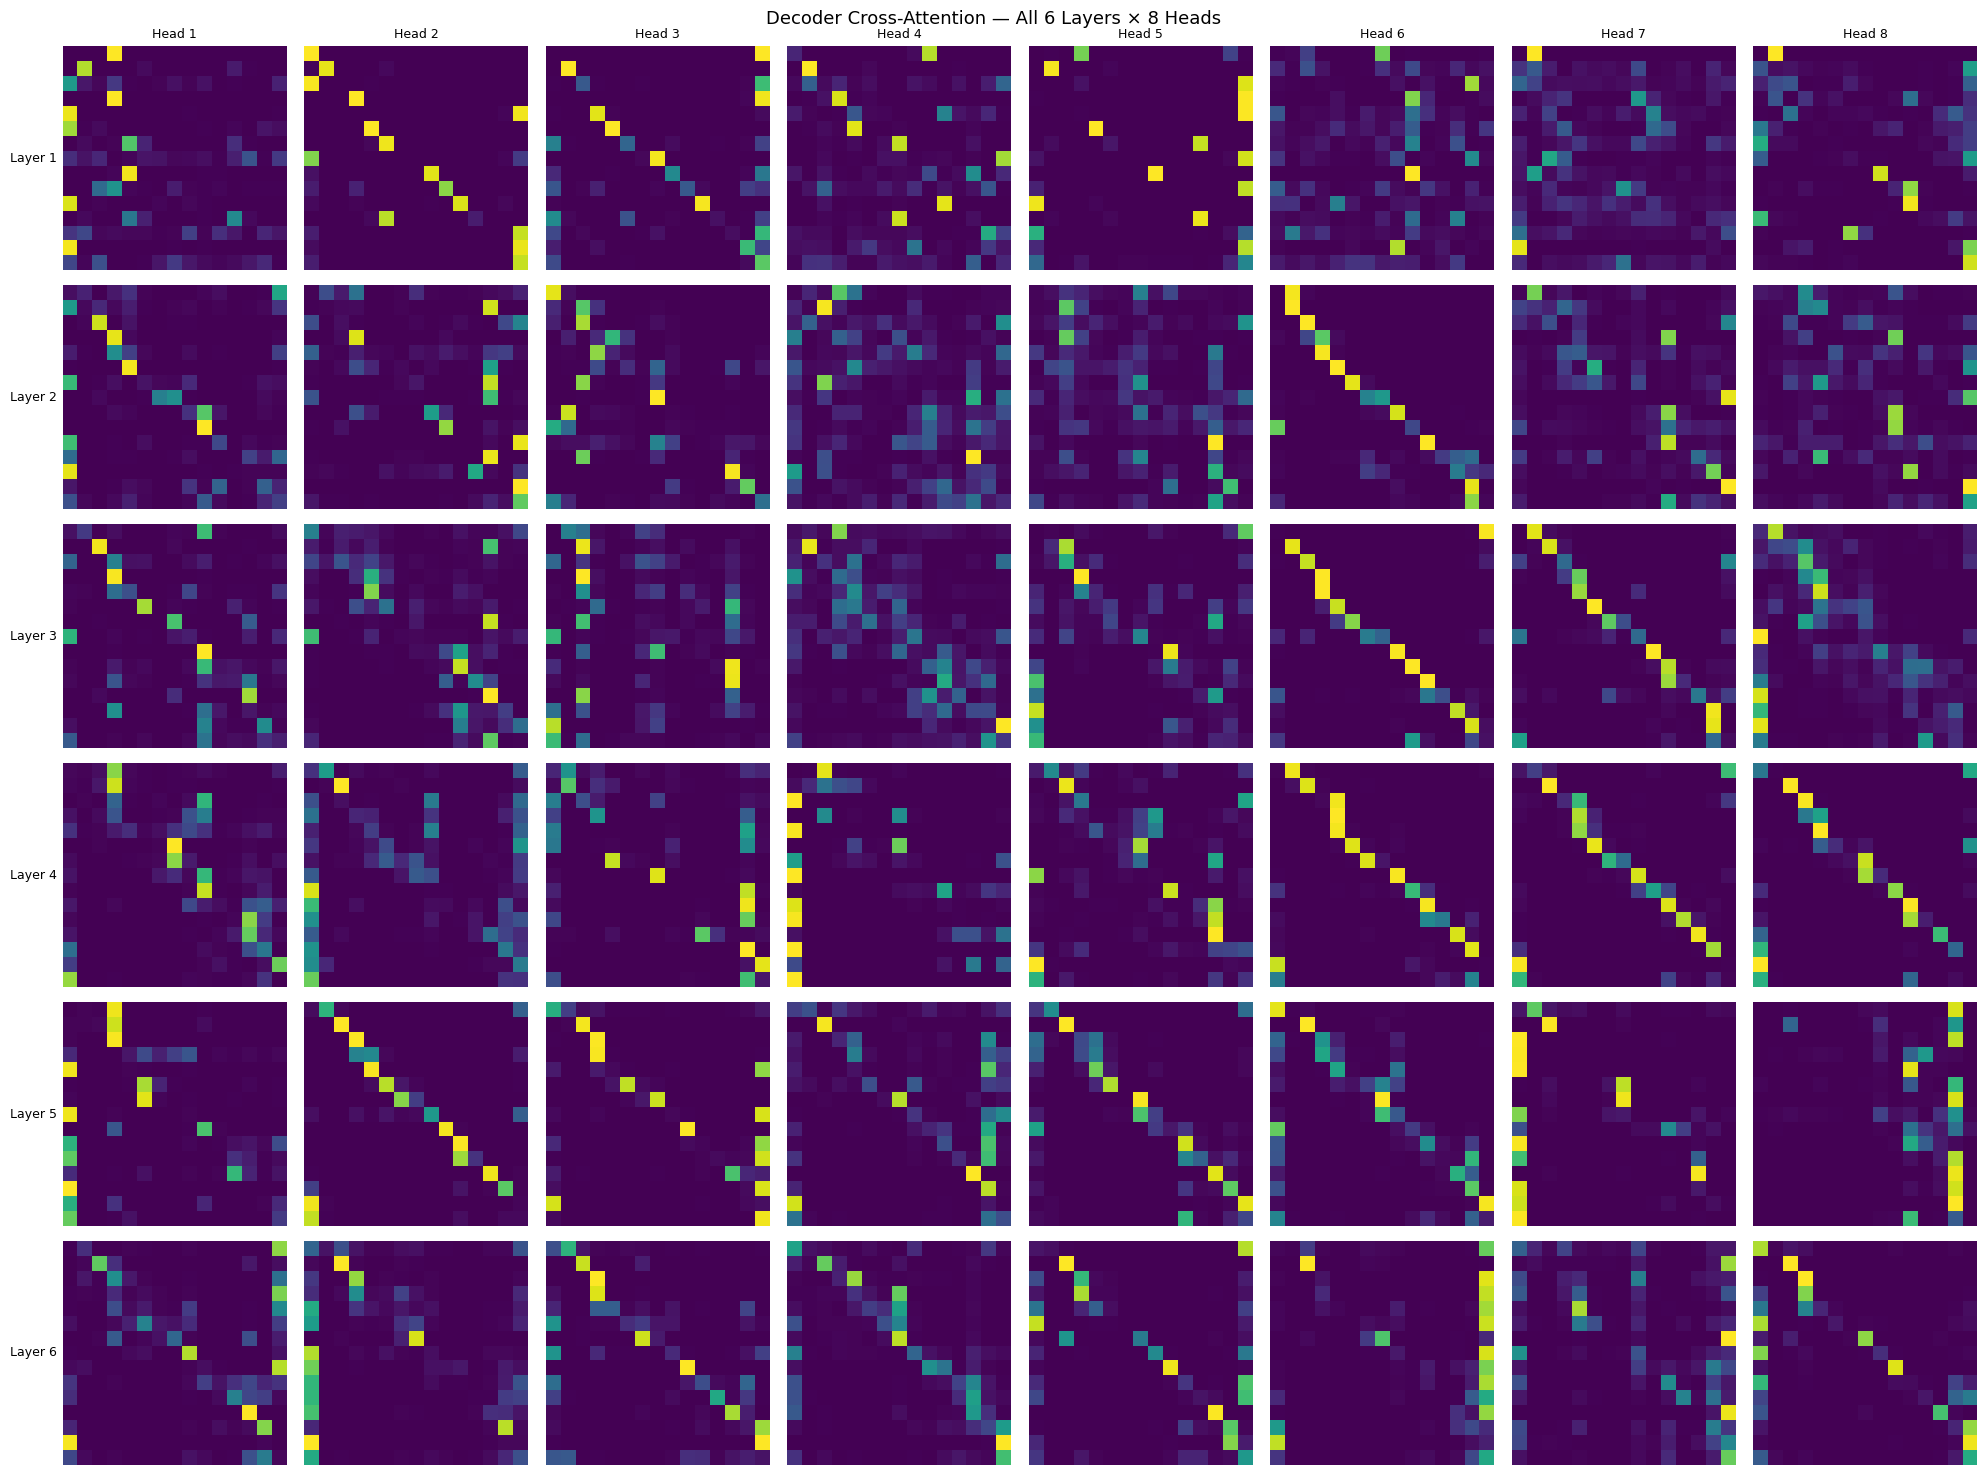

In [20]:
from visualization import plot_attention

# Grid of every decoder layer x every head at once, instead of one at a time.
# attn_type="cross" = decoder attending to source (same relation as the single
# heatmap above); "self" = decoder attending to its own previous tokens.
test_sentence = "Die Katze sitzt auf der Matte und schaut aus dem Fenster."

plot_attention(
    model=model,
    src_sentence=test_sentence,
    src_tokenizer=de_tok,
    tgt_tokenizer=en_tok,
    device=device,
    attn_type="cross",
    layer_idx=None,
    head_idx=None,
    save_path=None
)

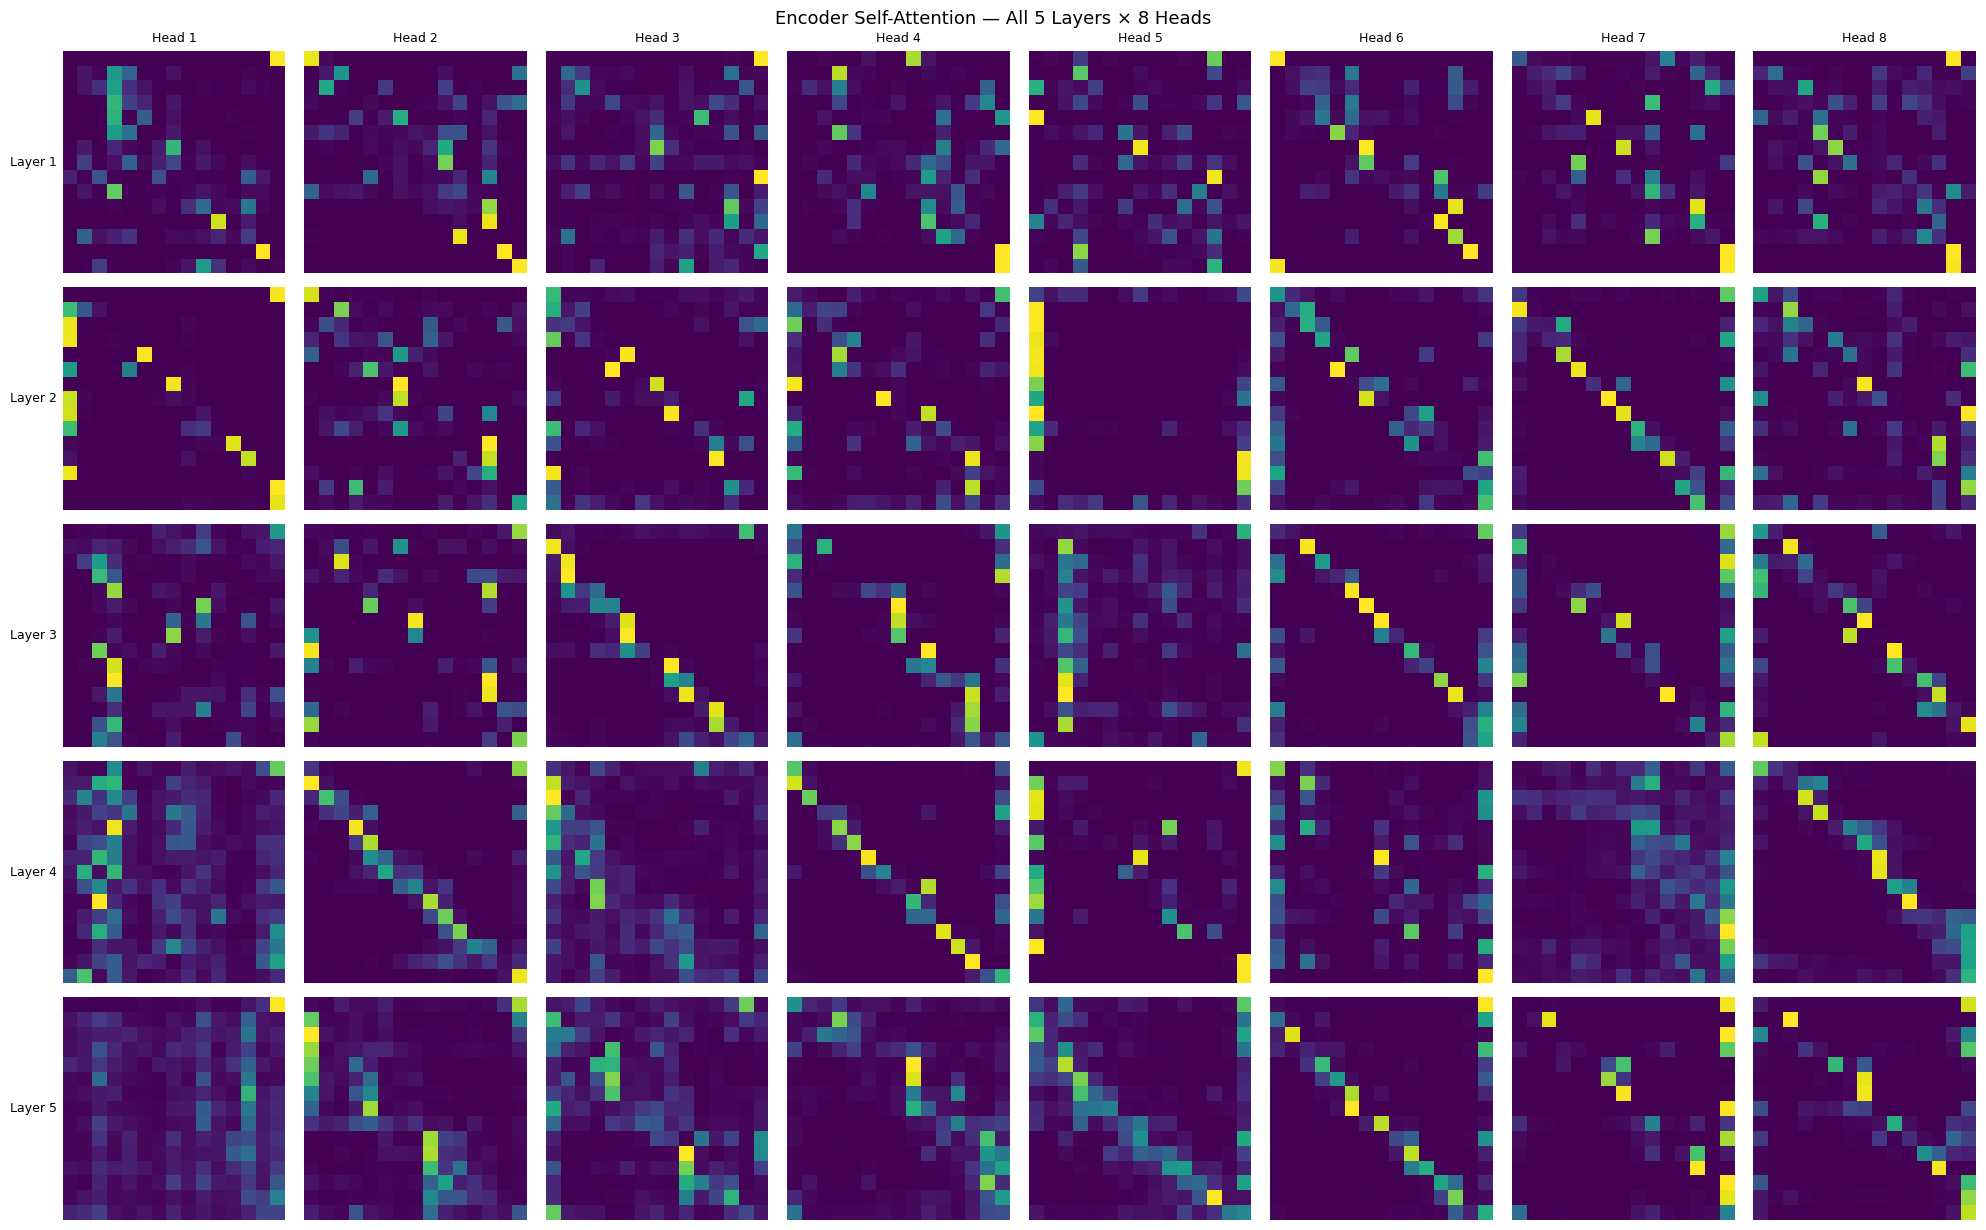

In [21]:
# Encoder self-attention — source tokens attending to each other. model.py's
# EncoderLayer.forward now captures and returns its attention weights too
# (enc_layer_{i}_self_attn), so this is plottable the same way as the decoder grids.
plot_attention(
    model=model,
    src_sentence=test_sentence,
    src_tokenizer=de_tok,
    tgt_tokenizer=en_tok,
    device=device,
    attn_type="encoder",
    layer_idx=None,
    head_idx=None,
    save_path=None
)

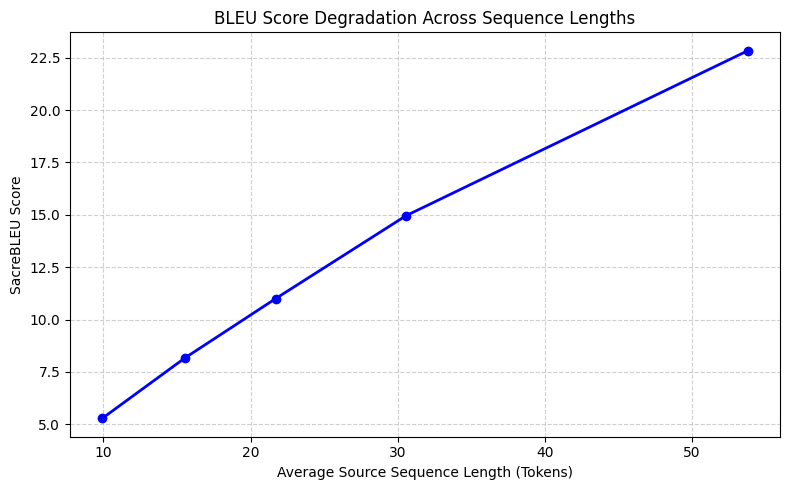

In [22]:
from evaluation import plot_bleu_vs_length

# max_len raised from 50 to 110, same reasoning and same value as the test
# eval cell above -- greedy decoding was found to fail to terminate (hit the
# generation cap without emitting EOS) on 82% of long val sentences at the
# old cap, which would otherwise distort exactly the longest bin(s) this
# plot exists to show.
plot_bleu_vs_length(
    model=model,
    dataloader=val_loader,
    tgt_tokenizer=en_tok,
    device=device,
    max_len=110,
    num_bins=5
)

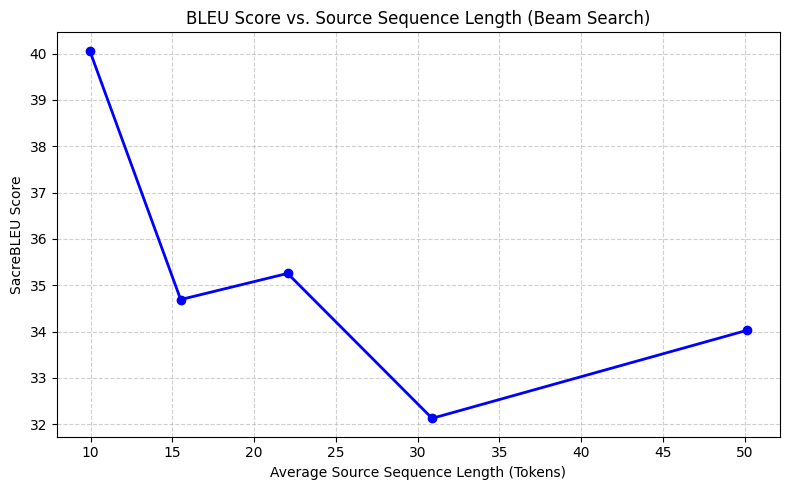

In [37]:
import importlib
import evaluation
importlib.reload(evaluation)
from evaluation import plot_bleu_vs_length

# Beam search variant of the plot above -- greedy decoding understates real
# quality (same reason the val/test BLEU investigation found earlier), so
# this is the one worth using in the writeup. Reuses val_sample_loader (the
# 500-sentence sample built earlier for the val-beam-search check) rather
# than the full val set: beam search decodes one sentence at a time, so
# running it over all 7,236 val sentences would take a long time for a plot.
plot_bleu_vs_length(
    model=model,
    dataloader=val_sample_loader,
    tgt_tokenizer=en_tok,
    src_tokenizer=de_tok,
    device=device,
    max_len=110,
    num_bins=5,
    use_beam_search=True,
    beam_size=4,
    alpha=0.6
)

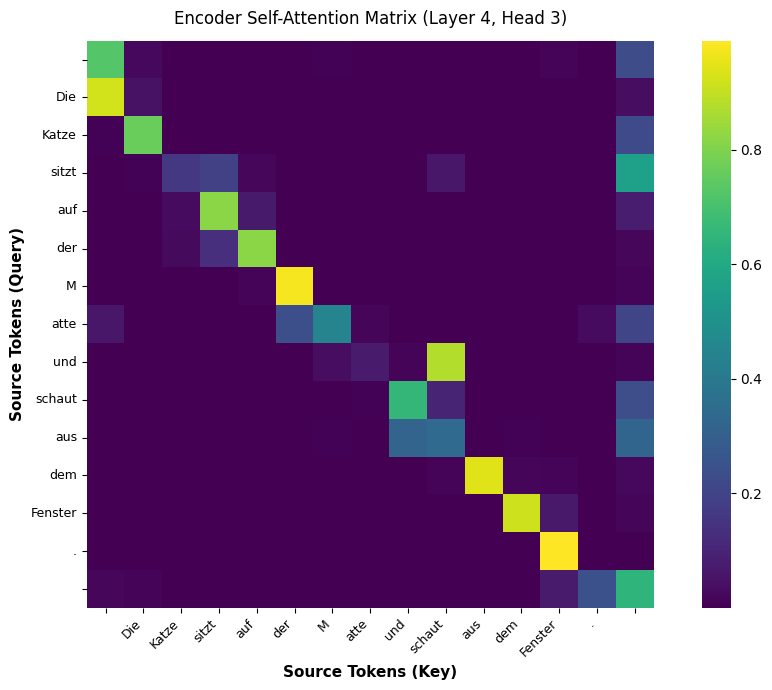

In [25]:
# Detailed single-head view: encoder self-attention, layer 3, head 3
# (layer_idx/head_idx are 0-indexed; layer_idx=2 -> "Layer 3", head_idx=2 -> "Head 3")
plot_attention(
    model=model,
    src_sentence=test_sentence,
    src_tokenizer=de_tok,
    tgt_tokenizer=en_tok,
    device=device,
    attn_type="encoder",
    layer_idx=3,
    head_idx=3,
    save_path=None
)

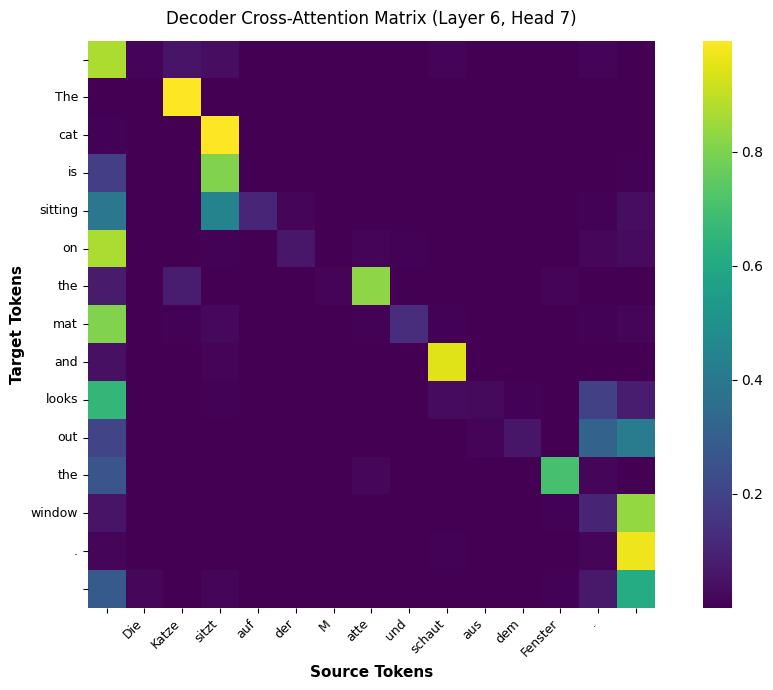

In [34]:
# Detailed single-head view: decoder cross-attention, layer 6, head 3
# (last decoder layer -- typically the cleanest source/target word-alignment pattern)
plot_attention(
    model=model,
    src_sentence=test_sentence,
    src_tokenizer=de_tok,
    tgt_tokenizer=en_tok,
    device=device,
    attn_type="cross",
    layer_idx=5,
    head_idx=7,
    save_path=None
)

Merged 93 epochs from 3 wandb runs (epoch range 1-94)


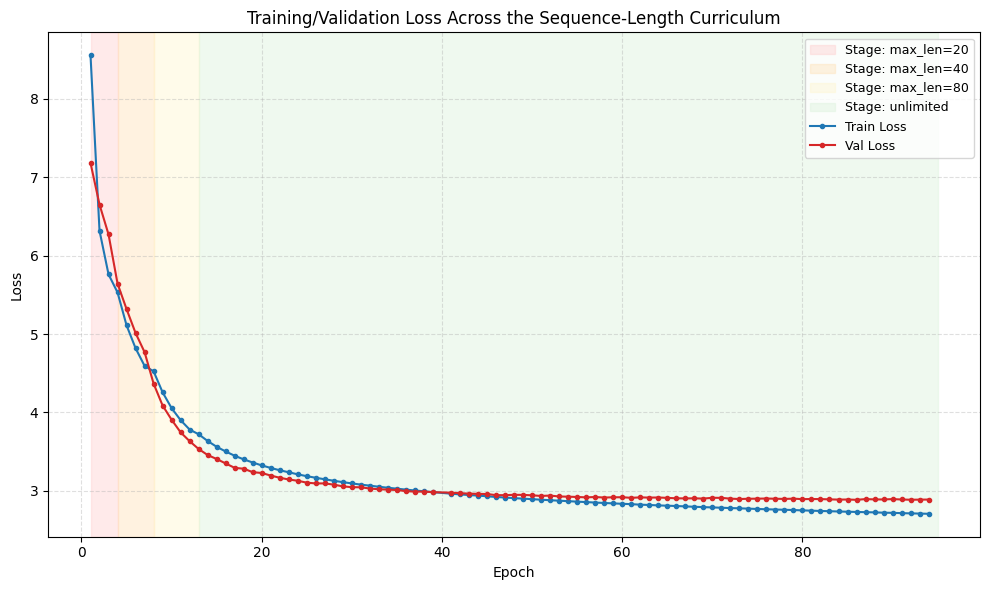

In [35]:
import wandb
import matplotlib.pyplot as plt

# Training spanned multiple kernel sessions (a fresh kernel is required before
# each resume, per the resume cell above), so the per-epoch history is split
# across separate wandb runs rather than one continuous one -- pull all of
# them and merge by epoch instead of relying on the notebook's own printed
# logs, which only show the LATEST re-run of the resume cell (epochs 21-35
# aren't visible in this notebook's text anymore for exactly that reason).
api = wandb.Api()
runs = api.runs("iwslt14-de-en-translation")

per_epoch = {}
for run in runs:
    if run.name != "transformer_best_run":
        continue
    for row in run.history(pandas=False):
        if row.get("train/epoch_loss") is None or row.get("val/loss") is None:
            continue
        epoch = row["epoch"]
        # Later runs overwrite earlier ones on overlapping epochs (e.g. 87-90
        # appears in both the 41-90 and 87-95 runs) -- iterating runs in
        # start-epoch order and always taking the latest write handles this.
        per_epoch[epoch] = (row["train/epoch_loss"], row["val/loss"])

epochs = sorted(per_epoch.keys())
train_losses = [per_epoch[e][0] for e in epochs]
val_losses = [per_epoch[e][1] for e in epochs]

print(f"Merged {len(epochs)} epochs from {len([r for r in runs if r.name == 'transformer_best_run'])} wandb runs "
      f"(epoch range {epochs[0]}-{epochs[-1]})")

# Sequence-length curriculum stage boundaries (see the Training section above)
CURRICULUM_BOUNDARIES = [
    (1, 3, "max_len=20"),
    (4, 7, "max_len=40"),
    (8, 12, "max_len=80"),
    (13, epochs[-1], "unlimited"),
]
STAGE_COLORS = ["#ffcccc", "#ffe0b3", "#fff5cc", "#d9f2d9"]

fig, ax = plt.subplots(figsize=(10, 6))

for (start, end, label), color in zip(CURRICULUM_BOUNDARIES, STAGE_COLORS):
    ax.axvspan(start, end + 1, color=color, alpha=0.4, label=f"Stage: {label}")

ax.plot(epochs, train_losses, marker='o', markersize=3, linewidth=1.5, color='tab:blue', label='Train Loss')
ax.plot(epochs, val_losses, marker='o', markersize=3, linewidth=1.5, color='tab:red', label='Val Loss')

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training/Validation Loss Across the Sequence-Length Curriculum")
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()